In [1]:
### Activate libraries that will be used in the notebook

import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm

import fanalysis.ca as fa 
from kmodes.kmodes import KModes
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns

import networkx as nx

import sqlite3 as sql



In [2]:
### Importer un module de fonctions crées ad hoc
##  ATTENTION : le fichier 'sparql_functions.py' doit se trouver 
#   dans un dossier qui se situe dans le chemin ('path') de recherche
#   vu par le présent carnet Jupyter afin que
#   l'importation fonctionne correctement

import sys
from importlib import reload


# Add parent directory to the path
sys.path.insert(0, '..')

### If you want to add the parent-parent directory,
sys.path.insert(0, '../..')



In [3]:

import bivariate_library as bl
import correspondence_analysis_library as cal
import cluster_functions as cf


In [4]:
### Use this to reload the functions if modified
print(reload(bl))
print(reload(cal))  

<module 'bivariate_library' from '/home/francesco/kDrive/python_notebooks/astronomers/notebooks_jupyter/wikidata_exploration/../bivariate_library.py'>
<module 'correspondence_analysis_library' from '/home/francesco/kDrive/python_notebooks/astronomers/notebooks_jupyter/wikidata_exploration/../correspondence_analysis_library.py'>


In [5]:
import warnings
warnings.filterwarnings('ignore')


## Create a dataframe with the data to be analysed

In this notebook, we use the data produced with the [bivariate analysis notebook using countries](da3-1_countries_bivariate_analysis.ipynb) and the data collected in the [da5-employer.md](../../documentation/wikidata/data-analysis/da5-employer.md) and [da5-employer.sql](../../documentation/wikidata/data-analysis/da5-employer.sql) files.




In [6]:
csv_address='da_data/da4-AFC.csv'
df_p = pd.read_csv(csv_address)
df_p.head(3)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,coded_country,activityYear,periodsActivity
0,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,1786,male,Cluses,POINT (6.578611 46.060278),http://www.wikidata.org/entity/Q654153,1781-1790,22,Western Europe,FR,France,France,FRA,France,1831,1826-1850
1,http://www.wikidata.org/entity/Q62336,Baron Wilhelm von Biela,1782,male,Roßla,POINT (11.076389 51.464722),http://www.wikidata.org/entity/Q699082,1781-1790,22,Western Europe,DE,Deutschland,Germany,DEU,Germany,1827,1826-1850
2,http://www.wikidata.org/entity/Q874465,József Csorba,1789,male,Vynohradiv,POINT (23.033056 48.139722),http://www.wikidata.org/entity/Q752334,1781-1790,8,Eastern Europe,UA,Україна,Ukraine,UKR,Ukraine,1834,1826-1850


In [7]:
df_p = df_p.drop(['CNTR_ID', 'CNTR_NAME', 'ISO3_CODE', 'activityYear', 'uriPlace', 'periods', 'FID', 'CNTR_ID'], axis=1)

In [8]:
### Inspect the dataframe and 
# notably if there are missing values
df_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20043 entries, 0 to 20042
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   uriPer           20043 non-null  object
 1   labelPer         20043 non-null  object
 2   birthYear        20043 non-null  int64 
 3   gender           20043 non-null  object
 4   labelPlace       20043 non-null  object
 5   geometry         20043 non-null  object
 6   REGION           20043 non-null  object
 7   NAME_ENGL        20043 non-null  object
 8   coded_country    20043 non-null  object
 9   periodsActivity  20043 non-null  object
dtypes: int64(1), object(9)
memory usage: 1.5+ MB


In [9]:
df_p=df_p.rename(columns={'uriPer': 'person_uri'})

In [10]:
df_p.head(1)

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,REGION,NAME_ENGL,coded_country,periodsActivity
0,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,1786,male,Cluses,POINT (6.578611 46.060278),Western Europe,France,France,1826-1850


In [11]:
pd.set_option('display.max_columns', None)
# Reset to default settings if needed later
# pd.reset_option('display.max_columns')

In [12]:
csv_address='da_data/da5-persons-features.csv'
# Explicitly tell pandas which strings to treat as NA (exclude 'NA' from the list)
# By default, pandas treats 'NA', 'N/A', 'NaN', etc. as missing values.
# If you want to override this by specifying a custom list that does NOT include 'NA'.
## df_pfeat = pd.read_csv(csv_address, na_values=['', 'N/A', 'NULL', 'None'])
df_pfeat = pd.read_csv(csv_address)
df_pfeat.head()

,pk_person_features,person_uri,occupation_main,occupation_sec1,coded_employer
0,2,http://www.wikidata.org/entity/Q1000934,physicist,university-teacher,education
1,3,http://www.wikidata.org/entity/Q100153910,physicist,university-teacher,education
2,5,http://www.wikidata.org/entity/Q100157315,physicist,university-teacher,university
3,8,http://www.wikidata.org/entity/Q100212,physicist,university-teacher,publisher
4,9,http://www.wikidata.org/entity/Q100216,physicist,university-teacher,institute


In [13]:
### Observe the 
df_pfeat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10900 entries, 0 to 10899
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   pk_person_features  10900 non-null  int64 
 1   person_uri          10900 non-null  object
 2   occupation_main     10900 non-null  object
 3   occupation_sec1     10900 non-null  object
 4   coded_employer      10900 non-null  object
dtypes: int64(1), object(4)
memory usage: 425.9+ KB


In [14]:
df_pm = pd.merge(df_p,df_pfeat, on='person_uri')  
# following used for inspection
# , how='left')

In [15]:
## The small number depends on the considered countries
df_pm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7946 entries, 0 to 7945
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   person_uri          7946 non-null   object
 1   labelPer            7946 non-null   object
 2   birthYear           7946 non-null   int64 
 3   gender              7946 non-null   object
 4   labelPlace          7946 non-null   object
 5   geometry            7946 non-null   object
 6   REGION              7946 non-null   object
 7   NAME_ENGL           7946 non-null   object
 8   coded_country       7946 non-null   object
 9   periodsActivity     7946 non-null   object
 10  pk_person_features  7946 non-null   int64 
 11  occupation_main     7946 non-null   object
 12  occupation_sec1     7946 non-null   object
 13  coded_employer      7946 non-null   object
dtypes: int64(2), object(12)
memory usage: 869.2+ KB


## Inspect distribution of variables

In [16]:
### Group and count: gender
# This variable creates a significant divide
df_count = df_pm.groupby('gender').size()
df_count = pd.DataFrame(df_count.sort_values(ascending = False))
df_count.columns=['number']
print(df_count.iloc[:50])



        number
gender        
male      7369
female     577


In [17]:
### Group and count: main occupation
# This variable creates a significant divide
df_count = df_pm.groupby('occupation_main').size()
df_count = pd.DataFrame(df_count.sort_values(ascending = False))
df_count.columns=['number']
print(df_count.iloc[:50])



                 number
occupation_main        
physicist          6488
astronomer         1458


In [18]:
### Group and count: country
df_count = df_pm.groupby('coded_country').size()
df_count = pd.DataFrame(df_count.sort_values(ascending = False))
df_count.columns=['number']
print(df_count.iloc[:50])



                           number
coded_country                    
Germany                      1545
United States Can.           1402
Russian Federation            747
United Kingdom                524
France                        423
Poland                        394
Italy                         387
Austria Hungary               314
Belgium Netherl.              291
Ukraine                       273
Baltic States Fin. Belar.     236
Czechia                       224
Scandinavia                   177
Spain Port.                   177
Switzerland                   168
Central Europe                161
Japan                         150
China                         123
India                         118
South America                 112


In [19]:
### Group and count: secondary occupation
# We observe some dispersion that requires grouping the categories of the variable
df_count = df_pm.groupby('occupation_sec1').size()
df_count = pd.DataFrame(df_count.sort_values(ascending = False))
df_count.columns=['number']
print(df_count.iloc[:50])



                          number
occupation_sec1                 
university-teacher          4947
mathematician                413
researcher                   394
astrophysicist               251
engineer                     224
nuclear-physicist            193
chemist                      166
theoretical-physicist        113
politician                   109
writer                        87
professor                     84
scientist                     54
teacher                       51
inventor                      50
meteorologist                 43
academic                      37
computer-scientist            31
biophysicist                  24
philosopher                   23
electrical-engineer           22
geophysicist                  20
discoverer-of-asteroids       16
photographer                  15
physician                     15
non-fiction-writer            14
translator                    13
historian-of-science          13
pedagogue                     12
science-co

In [20]:
### Group and count: coded employer
# We observe some dispersion that requires grouping the categories of the variable
df_count = df_pm.groupby('coded_employer').size()
df_count = pd.DataFrame(df_count.sort_values(ascending = False))
df_count.columns=['number']
print(df_count.iloc[:50])



                number
coded_employer        
education         2846
publisher         1761
institute         1119
university        1084
organization       402
agency             215
observatory        109
enterprise          98
other               64
GLAM                53
facility            41
college             40
school              39
academy             30
institution         14
laboratory          14
center              12
grande-école         5


In [21]:
### Group and count: activity periods
# We observe some dispersion that requires grouping the categories of the variable
df_count = df_pm.groupby('periodsActivity').size()
df_count = pd.DataFrame(df_count.sort_index())
df_count.columns=['number']
print(df_count.iloc[:50])



                 number
periodsActivity        
1826-1850           161
1851-1875           214
1876-1900           351
1901-1925           560
1926-1950           925
1951-1975          1925
1976-2000          2491
2001-2025          1319


## Cluster


### K-Modes clustering method

K-modes clustering is an unsupervised machine learning algorithm designed specifically for categorical data. It is an extension of the [K-means clustering algorithm](https://en.wikipedia.org/wiki/K-means_clustering), which works only with numerical data.

While K-means calculates the mean of data points to find cluster centers (centroids) and uses Euclidean distance (i.e. in the geometric space), K-modes adapts this process for categories:
* It uses the mode (the most frequent category) of the data points in a cluster to define the cluster center, rather than the arithmetic mean.
* Simple Matching Distance: It measures dissimilarity between data points by counting the number of mismatched categories (e.g., if two people have different colors, the distance increases by 1), rather than calculating geometric distance.
* Frequency-based Updates: The algorithm iteratively updates cluster modes based on the frequency of categories within each cluster.

[GitHub repository documentation of K-Modes](https://github.com/nicodv/kmodes)


### Choice of the variables

We have to decide which qualitative variables we will use for culstering and experiment with different situations.

&nbsp;

The approach we will test here is to use four basic features of the population: gender, country of origin, secondary (a more precise occupation then physicist/astronomers) and employer class, in order to create clusters.

We exclude the 'generation of activity' variable when clustering, but use it to situate the cluster within the flow of time, and to check whether some profiles are specific to a particular moment in time.

Also, in a first test, we also used the main occupation variable for clustering but this appears to be too dominant and hides more interesting phenomena: cf. this [representation of the clusters](images/kmodes_clusters_with_main_occupation.png) using the . 

We therefore exclude it from clustering and use it to inspect if some clusters are more specific to a main discipline



In [23]:
data_cat = df_pm[['gender', 'coded_country', 'occupation_sec1', 'coded_employer']].values
print(data_cat[:5])

[['male' 'France' 'mathematician' 'agency']
 ['male' 'Germany' 'chemist' 'university']
 ['male' 'Scandinavia' 'poet' 'agency']
 ['male' 'United Kingdom' 'geologist' 'education']
 ['male' 'United Kingdom' 'priest' 'organization']]


In [24]:
### 3. Determine Optimal Clusters (Elbow Method based on Cost)
# can take 10 minutes or more
costs = []
k_range = range(8, 24) # Your specified range
for k in k_range:
    km = KModes(n_clusters=k, init='Huang', n_init=20, verbose=0)
    km.fit_predict(data_cat)
    costs.append(km.cost_)

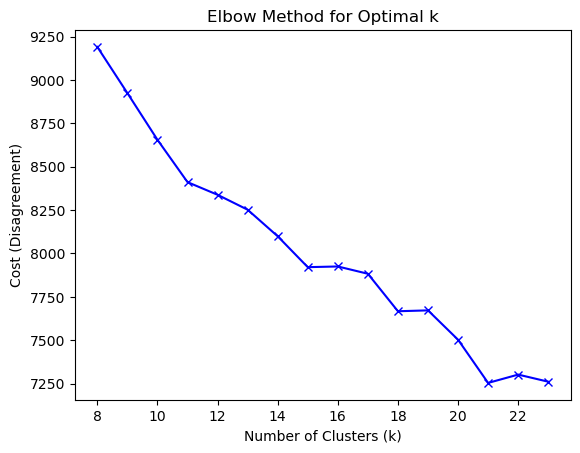

In [25]:
# Plot Elbow
plt.plot(k_range, costs, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Cost (Disagreement)')
plt.title('Elbow Method for Optimal k')
plt.show()

In [78]:
# Select k based on elbow (e.g., let's assume 30 for this run)
optimal_k = 15   
# 11, cost: 8614.0;   
# 15, cost: ...;  
# 21, cost : 7283.0

# 4. Fit Final Model
km_final = KModes(n_clusters=optimal_k, init='Huang', n_init=20, verbose=0)
df_pm['cluster'] = km_final.fit_predict(data_cat)
print(km_final.cost_)

7976.0


### Centroids and cost in K-Modes


The machine learning process calculates the distance of each individual in a cluster from the one individual that was chosen as the centroid or mode in the cluster.

The cost (often called the Total Dissimilarity or Objective Function) is the sum of mismatches between every individual and their assigned cluster center (mode).

In [28]:
### Inspect the data
df_pm.head(3)

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,REGION,NAME_ENGL,coded_country,periodsActivity,pk_person_features,occupation_main,occupation_sec1,coded_employer,cluster
0,http://www.wikidata.org/entity/Q715984,Joseph Nicollet,1786,male,Cluses,POINT (6.578611 46.060278),Western Europe,France,France,1826-1850,27877,astronomer,mathematician,agency,1
1,http://www.wikidata.org/entity/Q4274939,Johann Ludwig Georg Meinecke,1781,male,Stadthagen,POINT (9.206944 52.324722),Western Europe,Germany,Germany,1826-1850,20217,physicist,chemist,university,5
2,http://www.wikidata.org/entity/Q5598801,Jonas Brag,1781,male,Göteborg City,POINT (11.965228 57.704581),Northern Europe,Sweden,Scandinavia,1826-1850,23593,astronomer,poet,agency,1


In [63]:
### Get the centroids of the clusters
columns = ['gender', 'coded_country', 'occupation_sec1', 'coded_employer']
centroids_array = km_final.cluster_centroids_
centroid_df = pd.DataFrame(centroids_array, 
                           columns=columns)
centroid_df

,gender,coded_country,occupation_sec1,coded_employer
0,male,Austria Hungary,university-teacher,education
1,male,Germany,university-teacher,publisher
2,male,Germany,university-teacher,university
3,male,Switzerland,university-teacher,publisher
4,male,Russian Federation,university-teacher,publisher
5,male,Russian Federation,university-teacher,institute
6,male,United States Can.,university-teacher,education
7,male,Germany,university-teacher,institute
8,male,France,researcher,education
9,male,United Kingdom,university-teacher,education


### Is there a correspondence between clusters and generations

In [64]:
# 5. Validate against Generation (Unused Variable)
# Cross-tabulation : contingency_table
observed = pd.crosstab(df_pm['cluster'], df_pm['periodsActivity'])


In [65]:
bl.check_chi_square_test_validity(observed)

Table valid for Chi-square test: True


In [66]:
expected=bl.bivariate_stats(observed)

Chi-square : 487.22 , dof : 70
p-value : 0.0
Inertia (Phi-square):  0.061
Cramer:  0.094


### CA

In [67]:
afc = fa.CA(row_labels=observed.index,col_labels=observed.columns)
afc.fit(observed.values)

,n_components,None
,row_labels,"Index([0, 1, ...ame='cluster')"
,col_labels,Index(['1826-...iodsActivity')
,stats,True


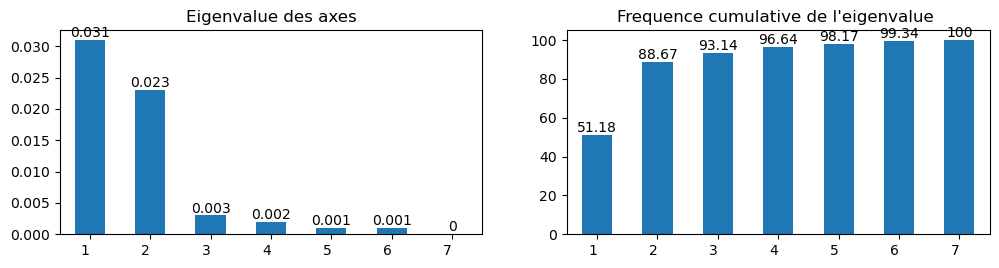

In [68]:
### Inertia (Phi-square - Eigenvalue):  0.108
cal.print_eigenvalue(afc)

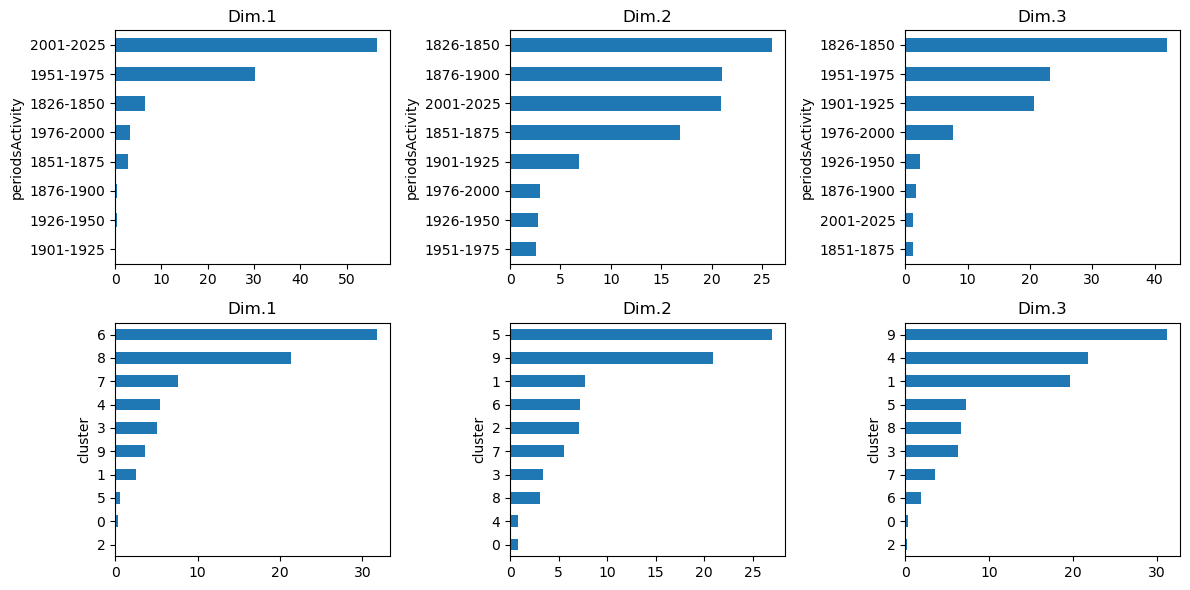

In [69]:
cal.dim_contributions(afc)

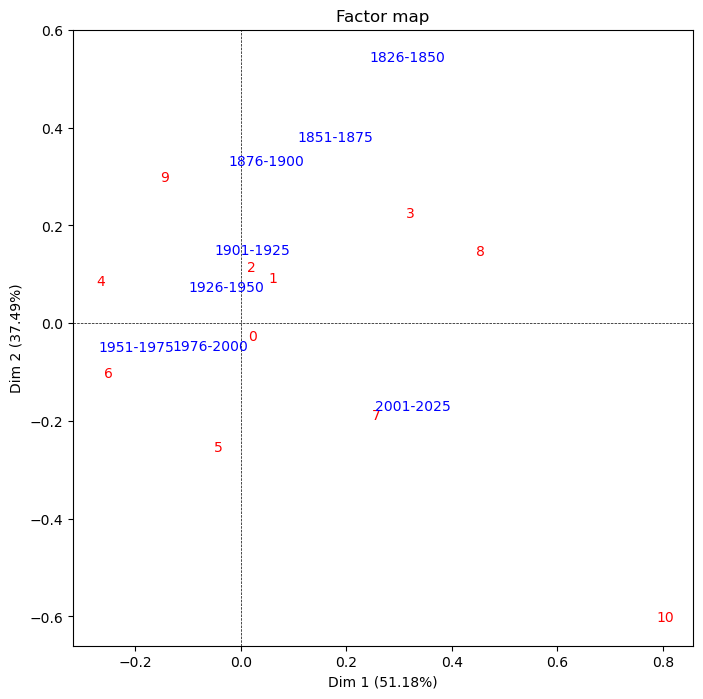

In [70]:
# Represent dimension 1 and 2
afc.mapping(num_x_axis=1,num_y_axis=2,figsize=(8,8))

In [ ]:
# Represent dimension 2 and 3
afc.mapping(num_x_axis=2,num_y_axis=3,figsize=(8,8))

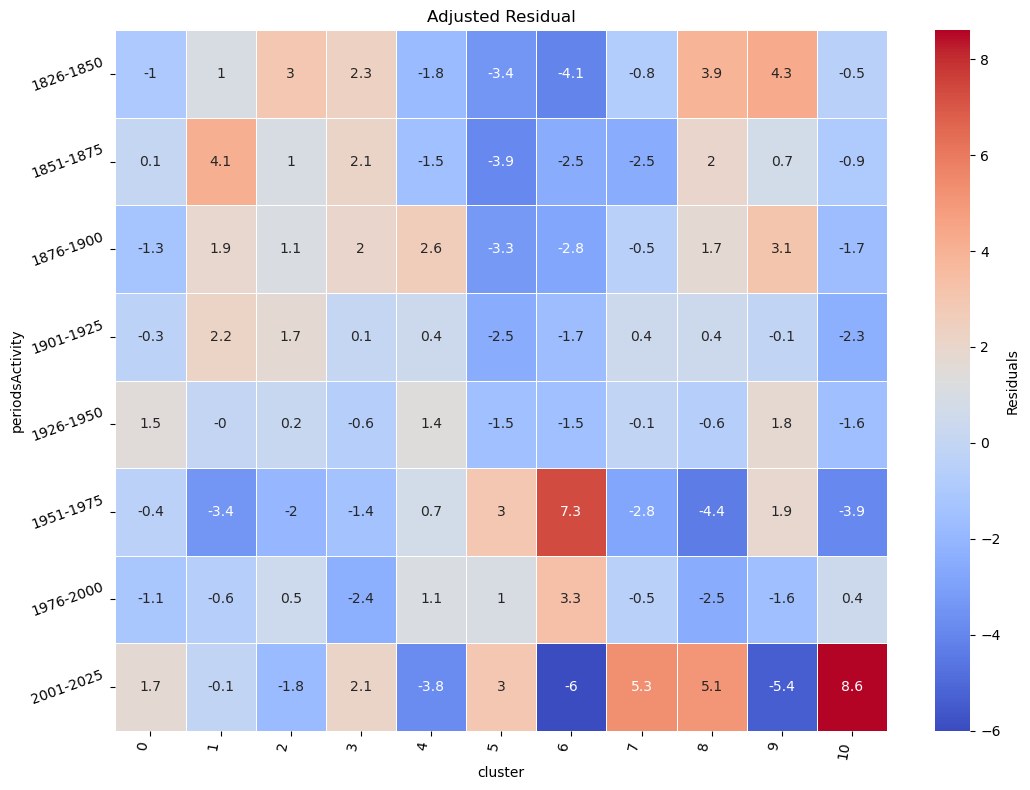

In [73]:
width= optimal_k
pp = bl.plot_chi2_residuals(observed.T, figsize=(optimal_k, 8))

In [74]:
### Inspect the centroids of the clusters
centroid_df

,gender,coded_country,occupation_sec1,coded_employer
0,male,Austria Hungary,university-teacher,education
1,male,Germany,university-teacher,publisher
2,male,Germany,university-teacher,university
3,male,Switzerland,university-teacher,publisher
4,male,Russian Federation,university-teacher,publisher
5,male,Russian Federation,university-teacher,institute
6,male,United States Can.,university-teacher,education
7,male,Germany,university-teacher,institute
8,male,France,researcher,education
9,male,United Kingdom,university-teacher,education


In [75]:
### size of the clusters
dfg = df_pm.groupby(by=['cluster']).size()
print(dfg.iloc[:30])

cluster
0     1878
1     1662
2     1007
3      122
4      194
5      759
6     1265
7      286
8      259
9      431
10      83
dtype: int64


In [76]:
dfg = pd.DataFrame(df_pm[df_pm.gender=='female'].groupby(by=['cluster']).size())
dfg.columns=['number']
(print(dfg.sort_values(by='number', ascending=False).iloc[:30]))

         number
cluster        
0           134
6           110
1           100
2            59
5            56
8            39
9            30
10           20
7            14
4            10
3             5


In [60]:
### write to database table for more deep inspection
db = '../../data/data_analysis.db'

conn = sql.connect(db)
# cursor = conn.cursor()
df_pm.to_sql('clusters_kmodes', conn, if_exists='append', index=True)
conn.close()

In [43]:
print(columns)

['gender', 'coded_country', 'occupation_sec1', 'coded_employer']


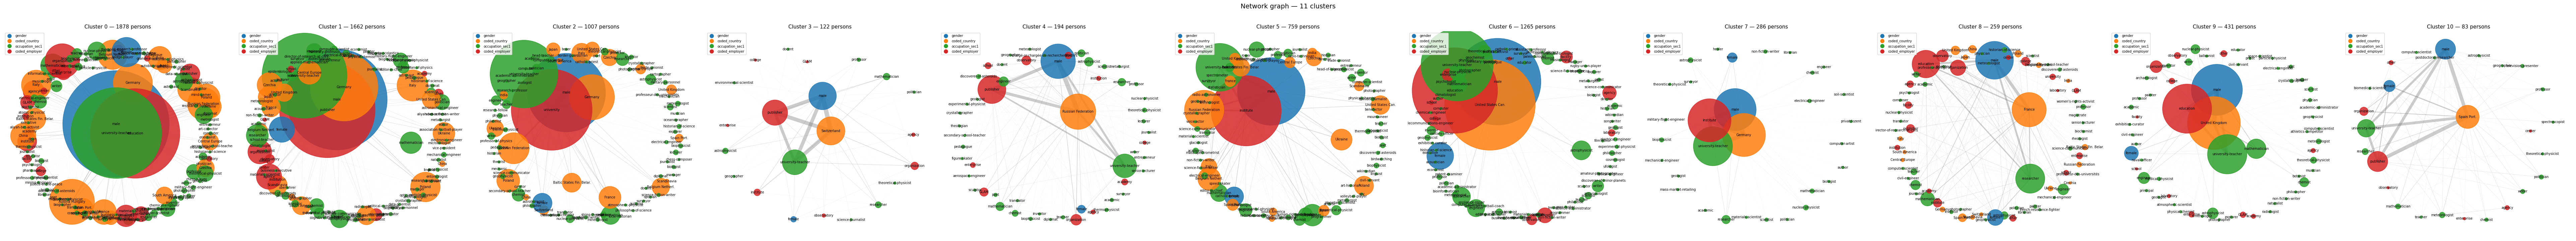

In [77]:
## ici on voit les attractions de modalités
# les variables au centre ou très liées structurent le cluster

cf.plot_cluster_networks(df_pm, columns, optimal_k)